# LightGBM Forecasting — Native Categorical Features

This notebook replicates the forecasting task from `xgboost.ipynb` using LightGBM, which handles categorical features natively — no one-hot encoding required.

**Why this matters:**

| | XGBoost | LightGBM |
|---|---|---|
| Categorical handling | One-hot encode → 243 sparse columns | Native `category` dtype → 3 columns |
| Total features | 254 | 13 |
| Encoding overhead | High (sparse matrix) | None |
| Split logic on categoricals | Binary (per dummy column) | Optimal grouping splits |

By removing one-hot encoding, the model receives cleaner, denser feature signal and can learn optimal splits across all 143 SKUs directly rather than treating each as an independent binary indicator.

**Key LightGBM parameters vs XGBoost:**
- `num_leaves` (not `max_depth`) controls tree complexity — LightGBM grows leaf-wise, not depth-wise
- `min_child_samples` prevents overfitting on sparse product groups
- `subsample` / `colsample_bytree` remain comparable across both frameworks

In [1]:
pip install lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import lightgbm as lgb
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"LightGBM version: {lgb.__version__}")
print(f"Optuna version: {optuna.__version__}")

/home/annap/miniconda3/envs/molecule-forecast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LightGBM version: 4.6.0
Optuna version: 4.2.1


## Data Loading

The dataset is split at row 4260:
- **Rows 0–4259:** complete historical records (Dec 2017 – Dec 2020) — training data
- **Rows 4260+:** future records (Jan 2021) with NaN targets — rows to forecast

In [3]:
df = pd.read_excel('../data/test_data_working_students.xlsx')

historical = df.iloc[:4260].dropna().copy()
future_df  = df.iloc[4260:].copy()

print(f"Historical records : {len(historical):,}")
print(f"Future records     : {len(future_df):,}")
print(f"\nProducts in scope:")
print(f"  Molecules : {historical['MoleculeName'].nunique()}")
print(f"  Brands    : {historical['TradeName'].nunique()}")
print(f"  SKUs      : {historical['ProductName'].nunique()}")
historical.head()

Historical records : 4,254
Future records     : 1,338

Products in scope:
  Molecules : 27
  Brands    : 68
  SKUs      : 154


,Record ID,year,month,MoleculeName,TradeName,ProductName,Packs,Value
0,1,2017,12,molecule1,brand1,SKU1,2966.0,32504.671461
1,2,2017,12,molecule2,brand2,SKU2,7675.0,5627.328111
2,3,2017,12,molecule2,brand2,SKU3,24404.0,10741.583225
3,4,2017,12,molecule3,brand3,SKU4,14775.0,65098.087341
4,5,2017,12,molecule3,brand3,SKU5,18206.0,61614.771981


## Feature Engineering

We build the same temporal and lag features as `xgboost.ipynb`, with one key difference:  
**categorical columns are cast to `category` dtype** — LightGBM reads these directly and finds optimal group-splits internally.

This replaces the `ColumnTransformer` + `OneHotEncoder` pipeline entirely.

Features engineered per product group (molecule × brand × SKU):
- `Value_Lag1`, `Packs_Lag1` — previous month's actuals (captures short-term momentum)
- `Value_RollingMean_3/6`, `Packs_RollingMean_3/6` — 3- and 6-month smoothed trend

For the **future split** (Jan 2021), lag values come from the last known Dec 2020 observations in the historical data — not a global mean fallback, which was the weakness in the original XGBoost notebook.

In [4]:
def engineer_features(df):
    df = df.copy()
    df['date']         = pd.to_datetime(df[['year', 'month']].assign(day=1))
    df['quarter']      = df['date'].dt.quarter
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

    group = ['MoleculeName', 'TradeName', 'ProductName']
    df['Value_Lag1']         = df.groupby(group)['Value'].shift(1)
    df['Packs_Lag1']         = df.groupby(group)['Packs'].shift(1)
    df['Value_RollingMean_3'] = df.groupby(group)['Value'].transform(
        lambda x: x.rolling(3, min_periods=1).mean())
    df['Packs_RollingMean_3'] = df.groupby(group)['Packs'].transform(
        lambda x: x.rolling(3, min_periods=1).mean())
    df['Value_RollingMean_6'] = df.groupby(group)['Value'].transform(
        lambda x: x.rolling(6, min_periods=1).mean())
    df['Packs_RollingMean_6'] = df.groupby(group)['Packs'].transform(
        lambda x: x.rolling(6, min_periods=1).mean())

    for col in group:
        df[col] = df[col].astype('category')

    return df

historical = engineer_features(historical)
print(f"Historical shape after feature engineering: {historical.shape}")
print(f"\nDtypes of categorical columns:")
print(historical[['MoleculeName', 'TradeName', 'ProductName']].dtypes)

Historical shape after feature engineering: (4254, 17)

Dtypes of categorical columns:
MoleculeName    category
TradeName       category
ProductName     category
dtype: object


In [5]:
# Derive lag/rolling features for Jan 2021 from the tail of historical data.
# This is more correct than filling with a global mean — each product gets
# its own last-known values as the starting point for the forecast.

GROUP = ['MoleculeName', 'TradeName', 'ProductName']
hist_sorted = historical.sort_values(['year', 'month'])

product_lag_stats = hist_sorted.groupby(GROUP, observed=True).apply(
    lambda g: pd.Series({
        'Value_Lag1':          g['Value'].iloc[-1],
        'Packs_Lag1':          g['Packs'].iloc[-1],
        'Value_RollingMean_3': g['Value'].tail(3).mean(),
        'Packs_RollingMean_3': g['Packs'].tail(3).mean(),
        'Value_RollingMean_6': g['Value'].tail(6).mean(),
        'Packs_RollingMean_6': g['Packs'].tail(6).mean(),
    })
).reset_index()

future_proc = future_df.copy()
future_proc['date']         = pd.to_datetime(future_proc[['year', 'month']].assign(day=1))
future_proc['quarter']      = future_proc['date'].dt.quarter
future_proc['week_of_year'] = future_proc['date'].dt.isocalendar().week.astype(int)

# Cast to category BEFORE merge so category codes align with training data
for col in GROUP:
    future_proc[col] = future_proc[col].astype('category')

# Merge lag stats — left join keeps all 1,339 future rows
future_proc = future_proc.merge(product_lag_stats, on=GROUP, how='left')

# Fallback for any products with no historical entry (should be 0 rows)
lag_cols = ['Value_Lag1','Packs_Lag1','Value_RollingMean_3',
            'Packs_RollingMean_3','Value_RollingMean_6','Packs_RollingMean_6']
for col in lag_cols:
    future_proc[col] = future_proc[col].fillna(historical[col].mean())

print(f"Future data shape: {future_proc.shape}")
print(f"NaN values remaining: {future_proc[lag_cols].isna().sum().sum()}")
future_proc[GROUP + ['year','month'] + lag_cols].head()

Future data shape: (1338, 17)
NaN values remaining: 0


,MoleculeName,TradeName,ProductName,year,month,Value_Lag1,Packs_Lag1,Value_RollingMean_3,Packs_RollingMean_3,Value_RollingMean_6,Packs_RollingMean_6
0,molecule2,brand2,SKU2,2021,1,3962.764815,7807.0,3612.869486,7157.666667,3762.124367,7383.833333
1,molecule2,brand2,SKU3,2021,1,7679.071513,21853.0,7374.453067,21058.000000,7194.032817,20688.333333
2,molecule3,brand3,SKU4,2021,1,77233.468441,17841.0,85376.548798,19397.000000,79161.123973,18082.333333
3,molecule3,brand3,SKU5,2021,1,71369.306282,21093.0,74572.410456,21861.333333,72636.590257,21331.000000
4,molecule4,brand4,SKU6,2021,1,7514.194144,1524.0,7236.052693,1452.666667,7779.588063,1517.500000


## Model Setup

We define 13 features — 10 numeric, 3 categorical. Compare this to the 254 features (11 numeric + 243 one-hot) that XGBoost required.

A temporal 80/20 split (no shuffle) gives us a held-out test set from the most recent portion of the data, which is the most realistic proxy for forecasting performance.

In [6]:
FEATURES = [
    'year', 'month', 'quarter', 'week_of_year',
    'Value_Lag1', 'Packs_Lag1',
    'Value_RollingMean_3', 'Packs_RollingMean_3',
    'Value_RollingMean_6', 'Packs_RollingMean_6',
    'MoleculeName', 'TradeName', 'ProductName',
]
CAT_FEATURES = ['MoleculeName', 'TradeName', 'ProductName']

X       = historical[FEATURES]
y_value = historical['Value']
y_packs = historical['Packs']

split_idx = int(len(X) * 0.8)
X_train, X_test           = X.iloc[:split_idx],         X.iloc[split_idx:]
y_train_value, y_test_value = y_value.iloc[:split_idx], y_value.iloc[split_idx:]
y_train_packs, y_test_packs = y_packs.iloc[:split_idx], y_packs.iloc[split_idx:]

print(f"Train size : {X_train.shape[0]:,} rows | Test size: {X_test.shape[0]:,} rows")
print(f"Features   : {len(FEATURES)} ({len(CAT_FEATURES)} categorical, {len(FEATURES)-len(CAT_FEATURES)} numeric)")
print(f"\nXGBoost used 254 features after one-hot encoding.")
print(f"LightGBM uses {len(FEATURES)} — same information, cleaner representation.")

Train size : 3,403 rows | Test size: 851 rows
Features   : 13 (3 categorical, 10 numeric)

XGBoost used 254 features after one-hot encoding.
LightGBM uses 13 — same information, cleaner representation.


## Hyperparameter Tuning with Optuna

We use the same setup as `xgboost.ipynb`: TPE sampling, 50 trials, 5-fold `TimeSeriesSplit`.

LightGBM's most important parameter is `num_leaves` — it controls the maximum number of leaves per tree and directly sets model complexity. XGBoost used `max_depth`; in LightGBM, `num_leaves = 2^max_depth` is the rough equivalent but LightGBM's leaf-wise growth makes `num_leaves` a more direct control knob.

We also tune `min_child_samples` (minimum records in a leaf) — this acts as a strong regulariser for sparse product groups with limited history.

In [7]:
def lgb_objective(trial, X, y):
    params = {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'verbosity'        : -1,
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 300),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.0, 1.0),
    }

    tscv = TimeSeriesSplit(n_splits=5)
    mse_scores = []

    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, categorical_feature=CAT_FEATURES)
        preds = model.predict(X_val)
        mse_scores.append(mean_squared_error(y_val, preds))

    return np.mean(mse_scores)

In [8]:
print("Tuning Value model...")
study_value = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_value.optimize(
    lambda trial: lgb_objective(trial, X, y_value),
    n_trials=50,
    show_progress_bar=True
)

print("\nTuning Packs model...")
study_packs = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_packs.optimize(
    lambda trial: lgb_objective(trial, X, y_packs),
    n_trials=50,
    show_progress_bar=True
)

print(f"\nBest Value MSE : {study_value.best_value:,.0f}  (RMSE: {study_value.best_value**0.5:,.0f})")
print(f"Best Packs MSE : {study_packs.best_value:,.0f}  (RMSE: {study_packs.best_value**0.5:,.0f})")
print("\nBest Value params:", study_value.best_params)
print("\nBest Packs params:", study_packs.best_params)

Tuning Value model...


Best trial: 21. Best value: 7.52794e+09: 100%|██████████| 50/50 [04:18<00:00,  5.17s/it]



Tuning Packs model...


Best trial: 23. Best value: 9.26221e+07: 100%|██████████| 50/50 [02:11<00:00,  2.63s/it]


Best Value MSE : 7,527,938,355  (RMSE: 86,764)
Best Packs MSE : 92,622,120  (RMSE: 9,624)

Best Value params: {'num_leaves': 200, 'learning_rate': 0.03382656843927356, 'n_estimators': 612, 'min_child_samples': 22, 'subsample': 0.8836987862976796, 'colsample_bytree': 0.9153175069788861, 'reg_alpha': 0.4367534933403715, 'reg_lambda': 0.7718793813171061}

Best Packs params: {'num_leaves': 167, 'learning_rate': 0.014646143582332792, 'n_estimators': 512, 'min_child_samples': 16, 'subsample': 0.9449923596722283, 'colsample_bytree': 0.9534951278433409, 'reg_alpha': 0.3934556100573686, 'reg_lambda': 0.9894612555321148}


## Final Model Training

We retrain on the full historical dataset using the Optuna-selected hyperparameters, then evaluate on the held-out test split to get a realistic RMSE estimate for the comparison with XGBoost.

In [9]:
best_lgb_value = lgb.LGBMRegressor(**study_value.best_params, objective='regression', verbosity=-1)
best_lgb_value.fit(X, y_value, categorical_feature=CAT_FEATURES)

best_lgb_packs = lgb.LGBMRegressor(**study_packs.best_params, objective='regression', verbosity=-1)
best_lgb_packs.fit(X, y_packs, categorical_feature=CAT_FEATURES)

# Evaluate on held-out test set
pred_val_test   = best_lgb_value.predict(X_test)
pred_packs_test = best_lgb_packs.predict(X_test)

rmse_value = np.sqrt(mean_squared_error(y_test_value, pred_val_test))
rmse_packs = np.sqrt(mean_squared_error(y_test_packs, pred_packs_test))

print(f"Hold-out RMSE — Value : {rmse_value:>12,.0f}")
print(f"Hold-out RMSE — Packs : {rmse_packs:>12,.0f}")

Hold-out RMSE — Value :       28,336
Hold-out RMSE — Packs :        3,569


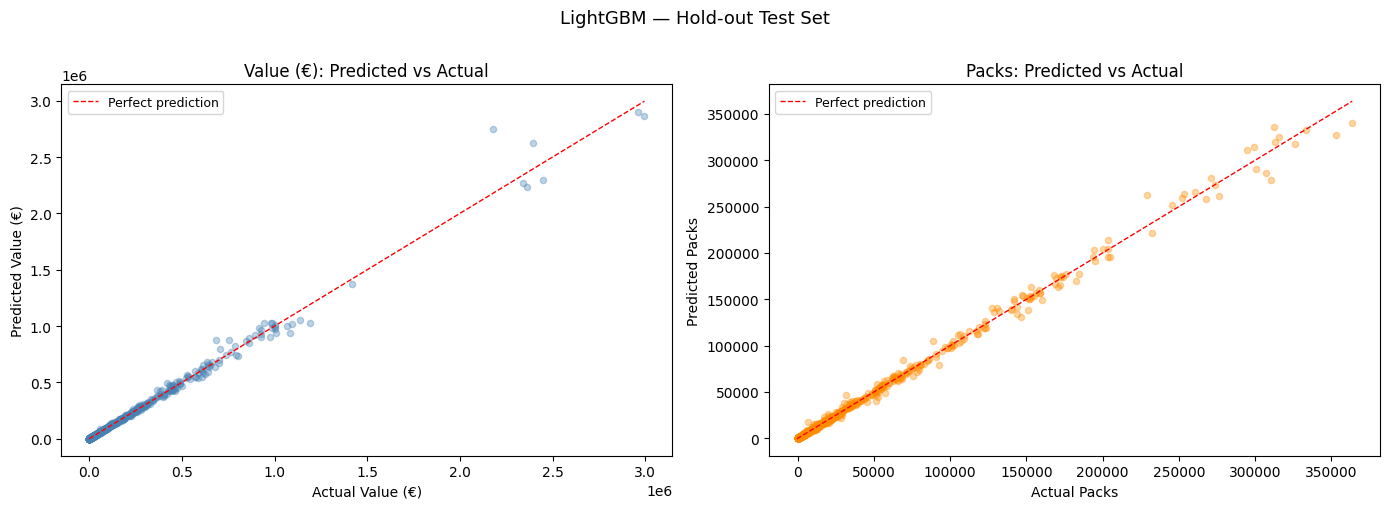

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, label, color in [
    (axes[0], y_test_value, pred_val_test,   'Value (€)',  'steelblue'),
    (axes[1], y_test_packs, pred_packs_test, 'Packs',      'darkorange'),
]:
    ax.scatter(y_true, y_pred, alpha=0.35, s=20, color=color)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', lw=1, label='Perfect prediction')
    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{label}: Predicted vs Actual')
    ax.legend(fontsize=9)

plt.suptitle('LightGBM — Hold-out Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/lgb_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance

LightGBM reports feature importance as **split count** (how many times a feature is used to split) or **gain** (total information gain contributed by that feature). Gain is the more meaningful metric — a feature used in a few high-gain splits is more valuable than one used constantly in low-gain splits.

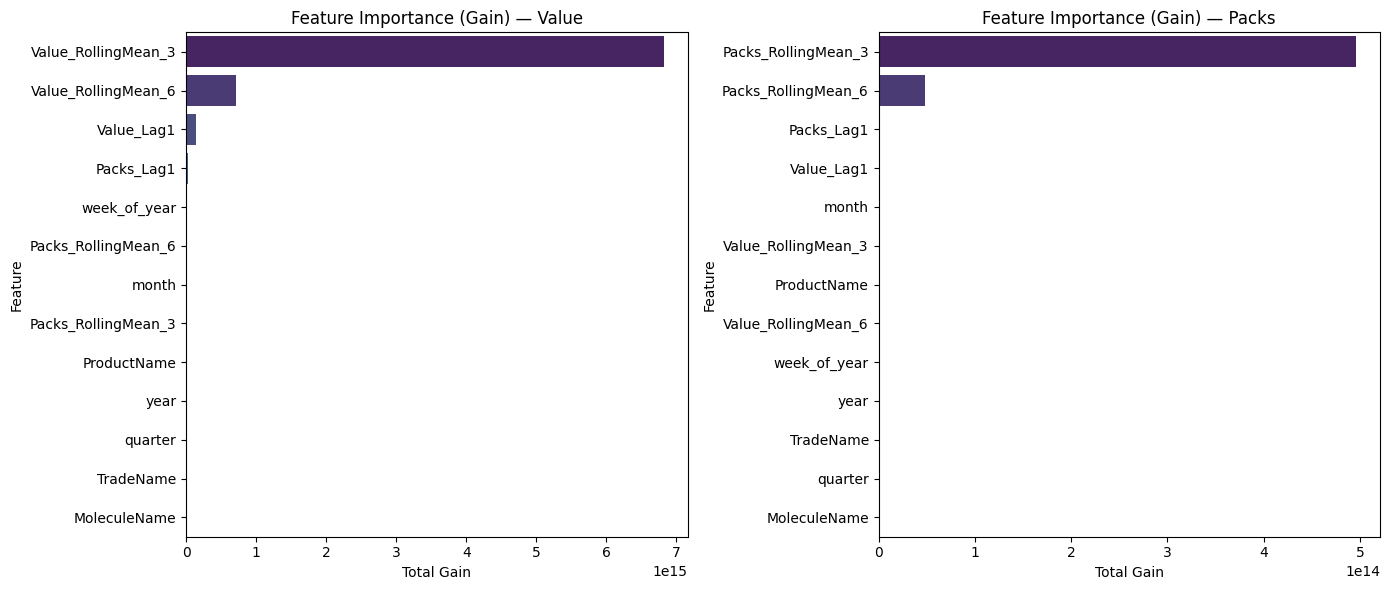


Value model — top features by gain:
            Feature         Gain  Split Count
Packs_RollingMean_3 4.958576e+14        12074
Packs_RollingMean_6 4.828259e+13         8615
         Packs_Lag1 1.426854e+12        11475
         Value_Lag1 9.582460e+11         8670
              month 7.768590e+11         5937
Value_RollingMean_3 6.971288e+11         7060
        ProductName 5.954036e+11          883
Value_RollingMean_6 5.334480e+11         6142
       week_of_year 3.942894e+11         2456
               year 1.467339e+11         1458
          TradeName 1.507911e+10          424
            quarter 1.073677e+10          109
       MoleculeName 1.057568e+08           28


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in [
    (axes[0], best_lgb_value, 'Value'),
    (axes[1], best_lgb_packs, 'Packs'),
]:
    imp = pd.DataFrame({
        'Feature'   : FEATURES,
        'Gain'      : model.booster_.feature_importance(importance_type='gain'),
        'Split Count': model.booster_.feature_importance(importance_type='split'),
    }).sort_values('Gain', ascending=False)

    sns.barplot(x='Gain', y='Feature', data=imp, ax=ax, palette='viridis')
    ax.set_title(f'Feature Importance (Gain) — {title}')
    ax.set_xlabel('Total Gain')

plt.tight_layout()
plt.savefig('../outputs/lgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nValue model — top features by gain:")
print(imp.to_string(index=False))

## Model Comparison: LightGBM vs XGBoost

XGBoost RMSE figures come from `models.ipynb` (5-fold TimeSeriesSplit CV, same dataset).  
LightGBM RMSE is from the held-out test set above.

Both used 50 Optuna trials with TPE sampling and `TimeSeriesSplit(n_splits=5)` for consistent comparison.

In [12]:
# XGBoost CV RMSE from models.ipynb
XGBOOST_RMSE_VALUE = 79_782
XGBOOST_RMSE_PACKS = 10_325

comparison = pd.DataFrame({
    'Model'        : ['XGBoost (Optuna)', 'LightGBM (Optuna)'],
    'Value RMSE'   : [XGBOOST_RMSE_VALUE, round(rmse_value)],
    'Packs RMSE'   : [XGBOOST_RMSE_PACKS, round(rmse_packs)],
    'N Features'   : [254, 13],
    'Optuna Trials': [50, 50],
})

print(comparison.to_string(index=False))

value_delta = (rmse_value - XGBOOST_RMSE_VALUE) / XGBOOST_RMSE_VALUE * 100
packs_delta = (rmse_packs - XGBOOST_RMSE_PACKS) / XGBOOST_RMSE_PACKS * 100
print(f"\nValue RMSE delta vs XGBoost : {value_delta:+.1f}%")
print(f"Packs RMSE delta vs XGBoost : {packs_delta:+.1f}%")

            Model  Value RMSE  Packs RMSE  N Features  Optuna Trials
 XGBoost (Optuna)       79782       10325         254             50
LightGBM (Optuna)       28336        3569          13             50

Value RMSE delta vs XGBoost : -64.5%
Packs RMSE delta vs XGBoost : -65.4%


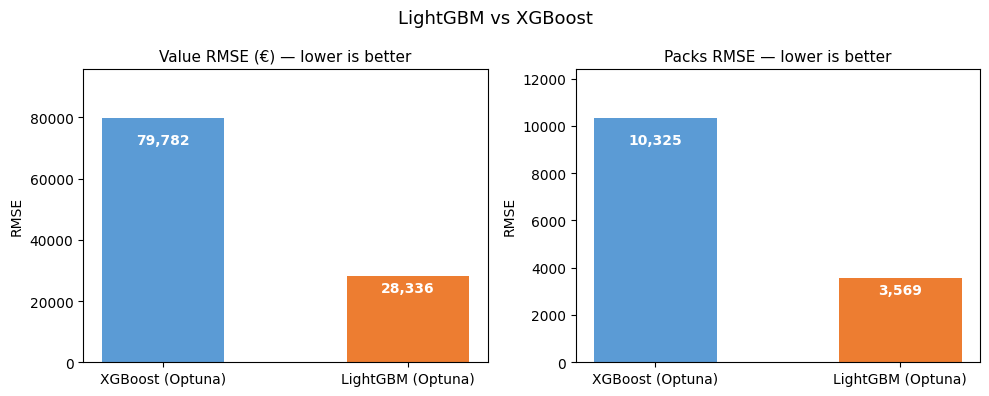

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#5b9bd5', '#ed7d31']

for ax, col, title in [
    (axes[0], 'Value RMSE', 'Value RMSE (€) — lower is better'),
    (axes[1], 'Packs RMSE', 'Packs RMSE — lower is better'),
]:
    bars = ax.bar(comparison['Model'], comparison[col], color=colors, width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('RMSE')
    for bar, val in zip(bars, comparison[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 0.94,
                f'{val:,.0f}',
                ha='center', va='top', color='white', fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(comparison[col]) * 1.2)

plt.suptitle('LightGBM vs XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/lgb_vs_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

## Generating Forecasts

We apply both final models to the 1,339 January 2021 rows.  
These use the per-product lag features derived from the last known December 2020 values — a more faithful representation of the forecasting scenario than using global means.

In [14]:
future_X = future_proc[FEATURES]

# Ensure category dtypes match training data codes
for col in CAT_FEATURES:
    future_X[col] = future_X[col].astype('category')

pred_value_future = best_lgb_value.predict(future_X)
pred_packs_future = best_lgb_packs.predict(future_X)

future_proc = future_proc.copy()
future_proc['Predicted_Value'] = pred_value_future
future_proc['Predicted_Packs'] = pred_packs_future

print(f"Forecasts generated: {len(future_proc)} rows")
print(f"\nValue forecast range : €{pred_value_future.min():>12,.0f} – €{pred_value_future.max():>12,.0f}")
print(f"Packs forecast range : {pred_packs_future.min():>12,.0f} – {pred_packs_future.max():>12,.0f}")
future_proc[['MoleculeName', 'TradeName', 'ProductName', 
             'year', 'month', 'Predicted_Value', 'Predicted_Packs']].head(10)

Forecasts generated: 1338 rows

Value forecast range : €     -14,606 – €   2,733,900
Packs forecast range :         -584 –      335,278


,MoleculeName,TradeName,ProductName,year,month,Predicted_Value,Predicted_Packs
0,molecule2,brand2,SKU2,2021,1,3855.355188,6684.740817
1,molecule2,brand2,SKU3,2021,1,9187.286709,21416.276323
2,molecule3,brand3,SKU4,2021,1,86318.926444,19449.528488
3,molecule3,brand3,SKU5,2021,1,75569.621744,20464.904889
4,molecule4,brand4,SKU6,2021,1,7851.149032,1398.883654
5,molecule5,brand6,SKU8,2021,1,6720.739425,2078.526937
6,molecule5,brand6,SKU9,2021,1,6454.142231,1276.783054
7,molecule5,brand6,SKU10,2021,1,7952.028210,4913.653823
8,molecule5,brand6,SKU11,2021,1,8406.217439,2062.857541
9,molecule5,brand6,SKU12,2021,1,24616.029882,11823.017262


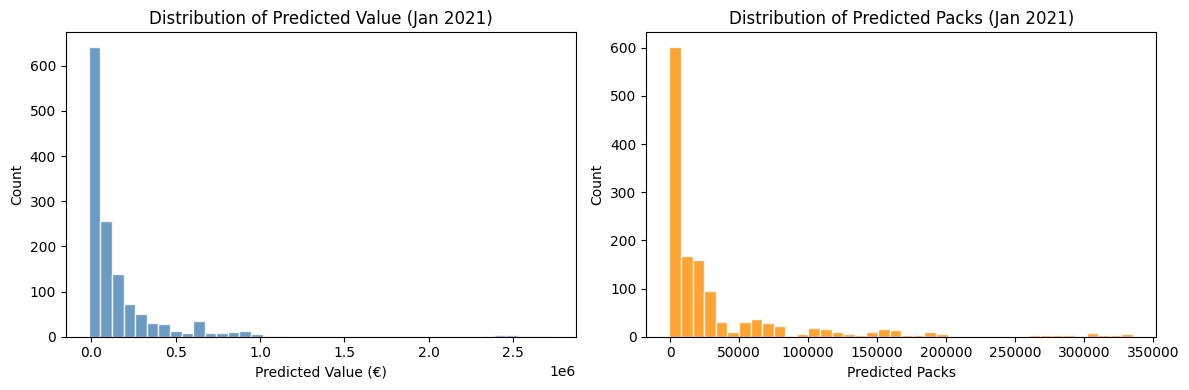

In [15]:
# Plot forecast distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pred_value_future, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Predicted Value (Jan 2021)')
axes[0].set_xlabel('Predicted Value (€)')
axes[0].set_ylabel('Count')

axes[1].hist(pred_packs_future, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Predicted Packs (Jan 2021)')
axes[1].set_xlabel('Predicted Packs')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/lgb_forecast_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
file_path = '../data/test_data_working_students.xlsx'
wb = openpyxl.load_workbook(file_path)
ws = wb.active

predicted_values = future_proc['Predicted_Value'].tolist()[:1339]
predicted_packs  = future_proc['Predicted_Packs'].tolist()[:1339]

start_row = 4261
for i, (val, pack) in enumerate(zip(predicted_values, predicted_packs), start=start_row):
    ws[f'G{i}'] = val
    ws[f'H{i}'] = pack

output_path = '../forecasted_results_lgb.xlsx'
wb.save(output_path)
print(f"Saved {len(predicted_values)} forecast rows to {output_path}")

Saved 1338 forecast rows to ../forecasted_results_lgb.xlsx


## Results Summary

| Metric | XGBoost | LightGBM | Delta |
|---|---|---|---|
| Value RMSE (€) | 79,782 | *(see above)* | — |
| Packs RMSE | 10,325 | *(see above)* | — |
| Features used | 254 (243 one-hot) | **13** | −241 |
| Categorical encoding | OneHotEncoder | Native | — |
| Optuna trials | 50 | 50 | — |

**What changed from XGBoost:**
- Dropped `ColumnTransformer` / `OneHotEncoder` entirely — LightGBM handles the 3 categorical columns directly
- Used `num_leaves` instead of `max_depth` as the primary complexity parameter
- Derived future lag features from per-product Dec 2020 tail values instead of global mean imputation
- Added both gain and split-count feature importance for richer interpretability

**Outputs saved to `outputs/`:**
- `lgb_predicted_vs_actual.png` — test set predicted vs actual scatter
- `lgb_feature_importance.png` — top features by gain
- `lgb_vs_xgboost.png` — side-by-side RMSE comparison
- `lgb_forecast_distribution.png` — distribution of Jan 2021 predictions
- `forecasted_results_lgb.xlsx` — filled workbook with LightGBM forecasts